In [1]:
import pandas as pd
import plotly.express as px
import nbformat
import numpy as np
import seaborn as sns
import os
from datetime import datetime
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from xgboost import XGBClassifier 
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
import xgboost as xgb
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import OneHotEncoder, KBinsDiscretizer
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import warnings
import pickle
# Ignore warnings to keep the output clean
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("../data/master_data.csv")

In [3]:
df.isnull().sum()

GENDER                                0
CUSTOMER_TYPE                         0
AGE                                   0
TYPE_OF_TRAVEL                        0
CLASS                                 0
FLIGHT_DISTANCE                       0
INFLIGHT_WIFI_SERVICE                 0
DEPARTURE_ARRIVAL_TIME_CONVENIENT     0
EASE_OF_ONLINE_BOOKING                0
GATE_LOCATION                         0
FOOD_AND_DRINK                        0
ONLINE_BOARDING                       0
SEAT_COMFORT                          0
INFLIGHT_ENTERTAINMENT                0
ON-BOARD_SERVICE                      0
LEG_ROOM_SERVICE                      0
BAGGAGE_HANDLING                      0
CHECKIN_SERVICE                       0
INFLIGHT_SERVICE                      0
CLEANLINESS                           0
DEPARTURE_DELAY_IN_MINUTES            0
ARRIVAL_DELAY_IN_MINUTES             83
SATISFACTION                          0
dtype: int64

In [4]:
df = df.dropna(subset=['ARRIVAL_DELAY_IN_MINUTES'])
df.shape

(25893, 23)

In [5]:

df.dtypes

GENDER                                object
CUSTOMER_TYPE                         object
AGE                                    int64
TYPE_OF_TRAVEL                        object
CLASS                                 object
FLIGHT_DISTANCE                        int64
INFLIGHT_WIFI_SERVICE                 object
DEPARTURE_ARRIVAL_TIME_CONVENIENT     object
EASE_OF_ONLINE_BOOKING                object
GATE_LOCATION                          int64
FOOD_AND_DRINK                        object
ONLINE_BOARDING                       object
SEAT_COMFORT                           int64
INFLIGHT_ENTERTAINMENT                object
ON-BOARD_SERVICE                      object
LEG_ROOM_SERVICE                      object
BAGGAGE_HANDLING                       int64
CHECKIN_SERVICE                        int64
INFLIGHT_SERVICE                      object
CLEANLINESS                           object
DEPARTURE_DELAY_IN_MINUTES             int64
ARRIVAL_DELAY_IN_MINUTES             float64
SATISFACTI

In [6]:
# List of columns to convert to category
category_columns = [
    'GENDER', 'CUSTOMER_TYPE', 'TYPE_OF_TRAVEL', 'CLASS', 'INFLIGHT_WIFI_SERVICE',
    'DEPARTURE_ARRIVAL_TIME_CONVENIENT', 'EASE_OF_ONLINE_BOOKING', 'GATE_LOCATION', 
    'FOOD_AND_DRINK', 'ONLINE_BOARDING', 'SEAT_COMFORT', 'INFLIGHT_ENTERTAINMENT', 
    'ON-BOARD_SERVICE', 'LEG_ROOM_SERVICE', 'BAGGAGE_HANDLING', 'CHECKIN_SERVICE', 
    'INFLIGHT_SERVICE', 'CLEANLINESS', 'SATISFACTION'
]

# List of columns to convert to int64
int64_columns = [
    'AGE', 'FLIGHT_DISTANCE', 'DEPARTURE_DELAY_IN_MINUTES', 'ARRIVAL_DELAY_IN_MINUTES'
]

# Convert the specified columns to category
df[category_columns] = df[category_columns].apply(lambda x: x.astype('category'))

# Convert the specified columns to int64
df[int64_columns] = df[int64_columns].apply(lambda x: x.astype('int64'))

# Verify the data types after conversion
print(df.dtypes)

GENDER                               category
CUSTOMER_TYPE                        category
AGE                                     int64
TYPE_OF_TRAVEL                       category
CLASS                                category
FLIGHT_DISTANCE                         int64
INFLIGHT_WIFI_SERVICE                category
DEPARTURE_ARRIVAL_TIME_CONVENIENT    category
EASE_OF_ONLINE_BOOKING               category
GATE_LOCATION                        category
FOOD_AND_DRINK                       category
ONLINE_BOARDING                      category
SEAT_COMFORT                         category
INFLIGHT_ENTERTAINMENT               category
ON-BOARD_SERVICE                     category
LEG_ROOM_SERVICE                     category
BAGGAGE_HANDLING                     category
CHECKIN_SERVICE                      category
INFLIGHT_SERVICE                     category
CLEANLINESS                          category
DEPARTURE_DELAY_IN_MINUTES              int64
ARRIVAL_DELAY_IN_MINUTES          

In [7]:
import pandas as pd

df_encoded = df.copy()
for col in df_encoded.select_dtypes(include=['category']).columns:
    df_encoded[col] = df_encoded[col].cat.codes  # Convert categories to integer codes

# Now, you can convert SATISFACTION to binary if it hasn't been done already
df_encoded['SATISFACTION_BINARY'] = df_encoded['SATISFACTION'].map({'Satisfied': 1, 'Neutral or Dissatisfied': 0})

# 1. Check categorical columns for low unique values
insignificant_columns = []

for col in df_encoded.select_dtypes(include=['category']):
    unique_count = df[col].nunique()
    if unique_count < 3:  # Low significance if fewer than 3 unique values
        insignificant_columns.append(col)

    # Check the distribution of categories
    value_counts = df[col].value_counts(normalize=True)
    if value_counts.max() > 0.9:  # If one category dominates
        insignificant_columns.append(col)

# 2. Check numerical columns for low variance
numerical_cols = df_encoded.select_dtypes(include=['int64']).columns
low_variance_threshold = 2  # Change based on your criteria

for col in numerical_cols:
    if df_encoded[col].nunique() <= low_variance_threshold:
        insignificant_columns.append(col)

# 3. Correlation analysis
correlation = df_encoded.corr()
correlation_target = correlation['SATISFACTION_BINARY'].abs().sort_values(ascending=False)
low_correlation_threshold = 0.1  # Adjust based on your needs

insignificant_columns += correlation_target[correlation_target < low_correlation_threshold].index.tolist()

# Remove duplicates
insignificant_columns = list(set(insignificant_columns))

# Output the insignificant columns
print("Insignificant columns for analysis:", insignificant_columns)


Insignificant columns for analysis: []


In [8]:
df.columns

Index(['GENDER', 'CUSTOMER_TYPE', 'AGE', 'TYPE_OF_TRAVEL', 'CLASS',
       'FLIGHT_DISTANCE', 'INFLIGHT_WIFI_SERVICE',
       'DEPARTURE_ARRIVAL_TIME_CONVENIENT', 'EASE_OF_ONLINE_BOOKING',
       'GATE_LOCATION', 'FOOD_AND_DRINK', 'ONLINE_BOARDING', 'SEAT_COMFORT',
       'INFLIGHT_ENTERTAINMENT', 'ON-BOARD_SERVICE', 'LEG_ROOM_SERVICE',
       'BAGGAGE_HANDLING', 'CHECKIN_SERVICE', 'INFLIGHT_SERVICE',
       'CLEANLINESS', 'DEPARTURE_DELAY_IN_MINUTES', 'ARRIVAL_DELAY_IN_MINUTES',
       'SATISFACTION'],
      dtype='object')

In [9]:
# Loop through the categorical columns and get unique values
columns = ['GENDER', 'CUSTOMER_TYPE', 'AGE', 'TYPE_OF_TRAVEL', 'CLASS',
       'FLIGHT_DISTANCE', 'INFLIGHT_WIFI_SERVICE',
       'DEPARTURE_ARRIVAL_TIME_CONVENIENT', 'EASE_OF_ONLINE_BOOKING',
       'GATE_LOCATION', 'FOOD_AND_DRINK', 'ONLINE_BOARDING', 'SEAT_COMFORT',
       'INFLIGHT_ENTERTAINMENT', 'ON-BOARD_SERVICE', 'LEG_ROOM_SERVICE',
       'BAGGAGE_HANDLING', 'CHECKIN_SERVICE', 'INFLIGHT_SERVICE',
       'CLEANLINESS', 'DEPARTURE_DELAY_IN_MINUTES', 'ARRIVAL_DELAY_IN_MINUTES',
       'SATISFACTION'
]

# Iterate through each category column and print the unique values
for col in columns:
    print(f"Unique values in '{col}':")
    print(df[col].unique())
    print()  # Add an empty line for better readability

Unique values in 'GENDER':
['Female', 'Male']
Categories (2, object): ['Female', 'Male']

Unique values in 'CUSTOMER_TYPE':
['Loyal', 'Disloyal']
Categories (2, object): ['Disloyal', 'Loyal']

Unique values in 'AGE':
[52 36 20 44 49 16 77 43 47 46 33 60 50 31 55 25 30 62 24 22 51 56 41 53
 12 39 32 40 42 28 59 58 27 67 70 66 19 69 35 54 26 61 21 37 45 38  7 34
 17 15 48 13 11 29  8 18 23 65 57 80 64  9 14 68 10 79 63 73 74 71 72 76
 78 75 85]

Unique values in 'TYPE_OF_TRAVEL':
['Business', 'Personal']
Categories (2, object): ['Business', 'Personal']

Unique values in 'CLASS':
['Eco', 'Business', 'Eco Plus']
Categories (3, object): ['Business', 'Eco', 'Eco Plus']

Unique values in 'FLIGHT_DISTANCE':
[ 160 2863  192 ... 3714 3097 3518]

Unique values in 'INFLIGHT_WIFI_SERVICE':
['5', '1', '2', 'Not Applicable', '3', '4']
Categories (6, object): ['1', '2', '3', '4', '5', 'Not Applicable']

Unique values in 'DEPARTURE_ARRIVAL_TIME_CONVENIENT':
['4', '1', 'Not Applicable', '3', '5', '2']
C

In [10]:
category_columns = [
    'GENDER', 'CUSTOMER_TYPE', 'TYPE_OF_TRAVEL', 'CLASS', 'INFLIGHT_WIFI_SERVICE',
    'DEPARTURE_ARRIVAL_TIME_CONVENIENT', 'EASE_OF_ONLINE_BOOKING', 'GATE_LOCATION', 
    'FOOD_AND_DRINK', 'ONLINE_BOARDING', 'SEAT_COMFORT', 'INFLIGHT_ENTERTAINMENT', 
    'ON-BOARD_SERVICE', 'LEG_ROOM_SERVICE', 'BAGGAGE_HANDLING', 'CHECKIN_SERVICE', 
    'INFLIGHT_SERVICE', 'CLEANLINESS', 'SATISFACTION'
]

int64_columns = [
    'AGE', 'FLIGHT_DISTANCE', 'DEPARTURE_DELAY_IN_MINUTES', 'ARRIVAL_DELAY_IN_MINUTES'
]

# Convert categorical columns to category dtype
df[category_columns] = df[category_columns].apply(lambda x: x.astype('category'))

# Convert the specified columns to int64
df[int64_columns] = df[int64_columns].apply(lambda x: x.astype('int64'))

# Drop rows with missing target variable (SATISFACTION)
df = df.dropna(subset=['SATISFACTION'])

# Encode categorical columns using integer codes (for easier modeling)
df_encoded = df.copy()
for col in df_encoded.select_dtypes(include=['category']).columns:
    df_encoded[col] = df_encoded[col].cat.codes  # Convert categories to integer codes

# Check the first few rows after encoding
df_encoded.head()


,GENDER,CUSTOMER_TYPE,AGE,TYPE_OF_TRAVEL,CLASS,FLIGHT_DISTANCE,INFLIGHT_WIFI_SERVICE,DEPARTURE_ARRIVAL_TIME_CONVENIENT,EASE_OF_ONLINE_BOOKING,GATE_LOCATION,...,INFLIGHT_ENTERTAINMENT,ON-BOARD_SERVICE,LEG_ROOM_SERVICE,BAGGAGE_HANDLING,CHECKIN_SERVICE,INFLIGHT_SERVICE,CLEANLINESS,DEPARTURE_DELAY_IN_MINUTES,ARRIVAL_DELAY_IN_MINUTES,SATISFACTION
0,0,1,52,0,1,160,4,3,2,3,...,4,4,4,4,1,4,4,50,44,1
1,0,1,36,0,0,2863,0,0,2,0,...,3,3,3,3,2,3,4,0,0,1
2,1,0,20,0,1,192,1,5,1,3,...,1,3,0,2,1,1,1,0,0,0
3,1,1,44,0,0,3377,5,5,5,1,...,0,0,0,0,2,0,3,0,6,1
4,0,1,49,0,1,1182,1,2,3,2,...,1,1,1,1,3,1,3,0,20,1


In [11]:
categorical_columns = [
    'GENDER', 'CUSTOMER_TYPE', 'TYPE_OF_TRAVEL', 'CLASS', 'INFLIGHT_WIFI_SERVICE',
    'DEPARTURE_ARRIVAL_TIME_CONVENIENT', 'EASE_OF_ONLINE_BOOKING', 'GATE_LOCATION', 
    'FOOD_AND_DRINK', 'ONLINE_BOARDING', 'SEAT_COMFORT', 'INFLIGHT_ENTERTAINMENT', 
    'ON-BOARD_SERVICE', 'LEG_ROOM_SERVICE', 'BAGGAGE_HANDLING', 'CHECKIN_SERVICE', 
    'INFLIGHT_SERVICE', 'CLEANLINESS'
]

numerical_columns = [
    'AGE', 'FLIGHT_DISTANCE', 'DEPARTURE_DELAY_IN_MINUTES', 'ARRIVAL_DELAY_IN_MINUTES'
]

target_column = 'SATISFACTION'

In [12]:
df_encoded.isnull().sum()

GENDER                               0
CUSTOMER_TYPE                        0
AGE                                  0
TYPE_OF_TRAVEL                       0
CLASS                                0
FLIGHT_DISTANCE                      0
INFLIGHT_WIFI_SERVICE                0
DEPARTURE_ARRIVAL_TIME_CONVENIENT    0
EASE_OF_ONLINE_BOOKING               0
GATE_LOCATION                        0
FOOD_AND_DRINK                       0
ONLINE_BOARDING                      0
SEAT_COMFORT                         0
INFLIGHT_ENTERTAINMENT               0
ON-BOARD_SERVICE                     0
LEG_ROOM_SERVICE                     0
BAGGAGE_HANDLING                     0
CHECKIN_SERVICE                      0
INFLIGHT_SERVICE                     0
CLEANLINESS                          0
DEPARTURE_DELAY_IN_MINUTES           0
ARRIVAL_DELAY_IN_MINUTES             0
SATISFACTION                         0
dtype: int64

In [17]:
categorical_columns = [
    'GENDER', 'CUSTOMER_TYPE', 'TYPE_OF_TRAVEL', 'CLASS', 'INFLIGHT_WIFI_SERVICE',
    'DEPARTURE_ARRIVAL_TIME_CONVENIENT', 'EASE_OF_ONLINE_BOOKING', 'GATE_LOCATION', 
    'FOOD_AND_DRINK', 'ONLINE_BOARDING', 'SEAT_COMFORT', 'INFLIGHT_ENTERTAINMENT', 
    'ON-BOARD_SERVICE', 'LEG_ROOM_SERVICE', 'BAGGAGE_HANDLING', 'CHECKIN_SERVICE', 
    'INFLIGHT_SERVICE', 'CLEANLINESS'
]

# Numerical columns for discretization
numerical_columns = [
    'AGE', 'FLIGHT_DISTANCE', 'DEPARTURE_DELAY_IN_MINUTES', 'ARRIVAL_DELAY_IN_MINUTES'
]

# Preprocessor pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='mean')),
            ('scaler', StandardScaler()),
            ('discretizer', KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='uniform'))
        ]), numerical_columns),
        
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_columns)
    ])

In [18]:
# Prepare data for model
X = df_encoded.drop(columns=[target_column, 'SATISFACTION'])
y = df_encoded[target_column]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
models = {
    'Gradient Boosting': GradientBoostingClassifier(),
    'XGBoost': xgb.XGBClassifier(eval_metric='mlogloss')
}

In [20]:
def plot_cm(cm, model_name, labels):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot()
    plt.gca().grid(False)
    plt.title(f"{model_name} Confusion Matrix")
    plt.show()

Training model: Gradient Boosting
Classification Report for Gradient Boosting:

              precision    recall  f1-score   support

           0       0.94      0.96      0.95      2890
           1       0.95      0.92      0.94      2289

    accuracy                           0.95      5179
   macro avg       0.95      0.94      0.95      5179
weighted avg       0.95      0.95      0.95      5179



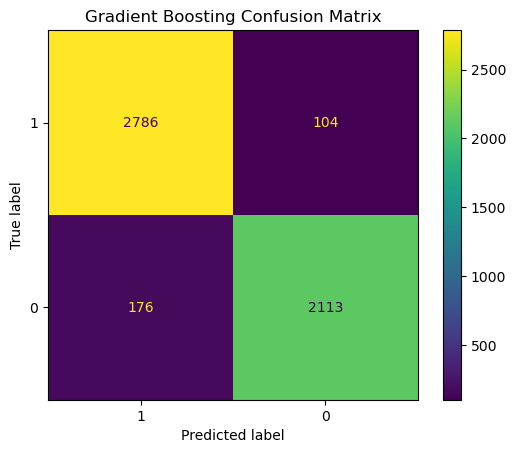

Training model: XGBoost
Classification Report for XGBoost:

              precision    recall  f1-score   support

           0       0.95      0.98      0.96      2890
           1       0.97      0.93      0.95      2289

    accuracy                           0.96      5179
   macro avg       0.96      0.95      0.96      5179
weighted avg       0.96      0.96      0.96      5179



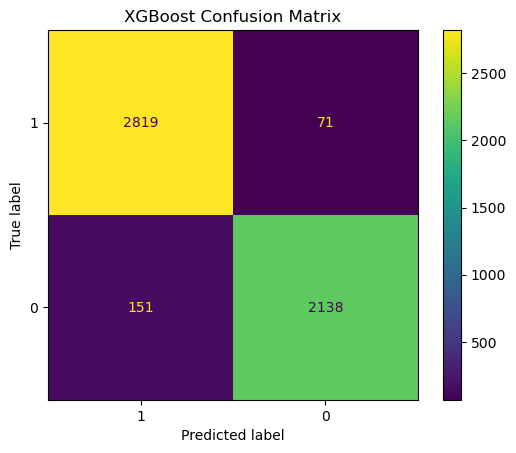

Tuning model: Gradient Boosting
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters for Gradient Boosting: {'classifier__subsample': 1.0, 'classifier__n_estimators': 200, 'classifier__min_samples_split': 10, 'classifier__min_samples_leaf': 4, 'classifier__max_depth': 5, 'classifier__learning_rate': 0.1}
Best Score for Gradient Boosting: 0.9583857189485174
Classification Report for Gradient Boosting:

              precision    recall  f1-score   support

           0       0.95      0.98      0.96      2890
           1       0.97      0.94      0.95      2289

    accuracy                           0.96      5179
   macro avg       0.96      0.96      0.96      5179
weighted avg       0.96      0.96      0.96      5179



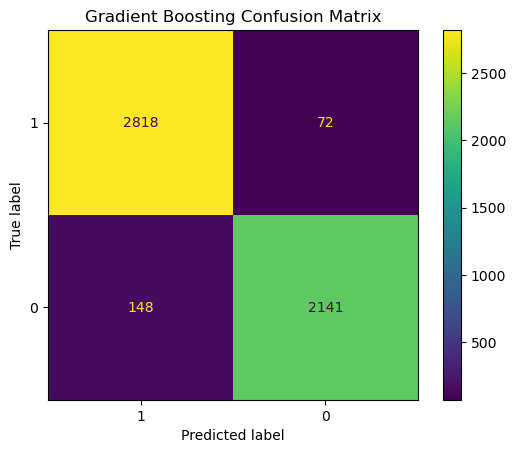

Tuning model: XGBoost
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters for XGBoost: {'classifier__subsample': 0.8, 'classifier__n_estimators': 100, 'classifier__min_child_weight': 5, 'classifier__max_depth': 7, 'classifier__learning_rate': 0.1, 'classifier__colsample_bytree': 0.9}
Best Score for XGBoost: 0.9577580355142586
Classification Report for XGBoost:

              precision    recall  f1-score   support

           0       0.95      0.98      0.96      2890
           1       0.97      0.93      0.95      2289

    accuracy                           0.96      5179
   macro avg       0.96      0.95      0.96      5179
weighted avg       0.96      0.96      0.96      5179



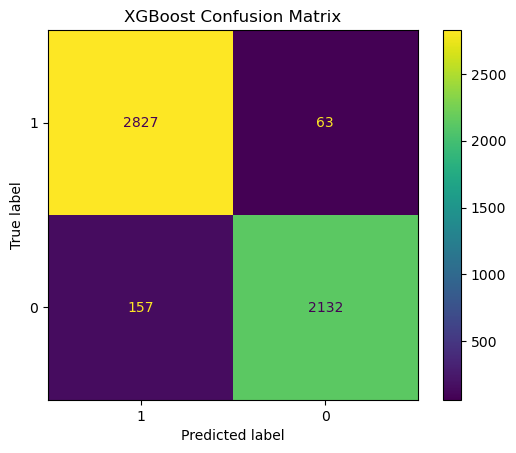

In [24]:
for model_name, model in models.items():
    print(f"Training model: {model_name}")
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    
    print(f"Classification Report for {model_name}:\n")
    print(classification_report(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred)
    
    plot_cm(cm, model_name, labels=y_test.unique())

param_grids = {
    'Gradient Boosting': {
        'classifier__n_estimators': [100, 200, 300],
        'classifier__learning_rate': [0.001, 0.01, 0.1, 0.2],
        'classifier__max_depth': [3, 5, 7],
        'classifier__subsample': [0.8, 0.9, 1.0],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__min_samples_leaf': [1, 2, 4],
    },
    'XGBoost': {
        'classifier__n_estimators': [100, 200, 300],
        'classifier__learning_rate': [0.001, 0.01, 0.1],
        'classifier__max_depth': [3, 5, 7],
        'classifier__min_child_weight': [1, 5, 10],
        'classifier__subsample': [0.8, 0.9, 1.0],
        'classifier__colsample_bytree': [0.8, 0.9, 1.0],
    }
}

for model_name, model in models.items():
    print(f"Tuning model: {model_name}")
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    random_search = RandomizedSearchCV(pipeline, param_distributions=param_grids[model_name], 
                                       n_iter=10, cv=3, verbose=1, random_state=42, n_jobs=-1)
    
    random_search.fit(X_train, y_train)
    
    print(f"Best Parameters for {model_name}: {random_search.best_params_}")
    print(f"Best Score for {model_name}: {random_search.best_score_}")

    y_pred = random_search.best_estimator_.predict(X_test)
    
    print(f"Classification Report for {model_name}:\n")
    print(classification_report(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred)
    
    plot_cm(cm, model_name, labels=y_test.unique())

Plotting AUPRC for Gradient Boosting


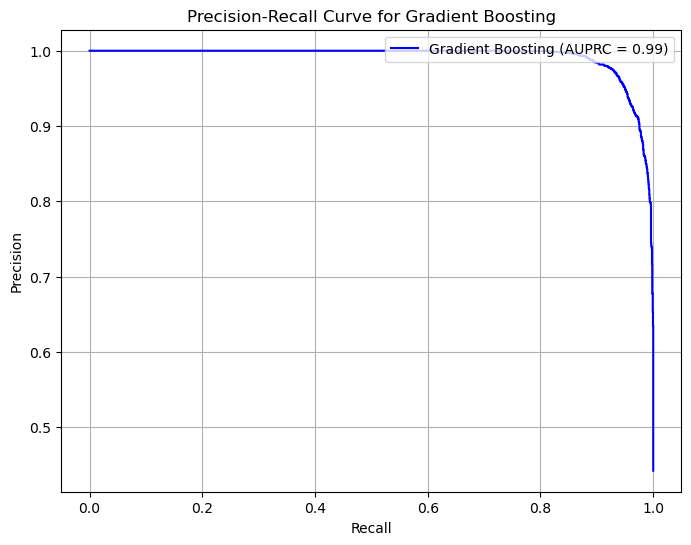

Plotting AUPRC for XGBoost


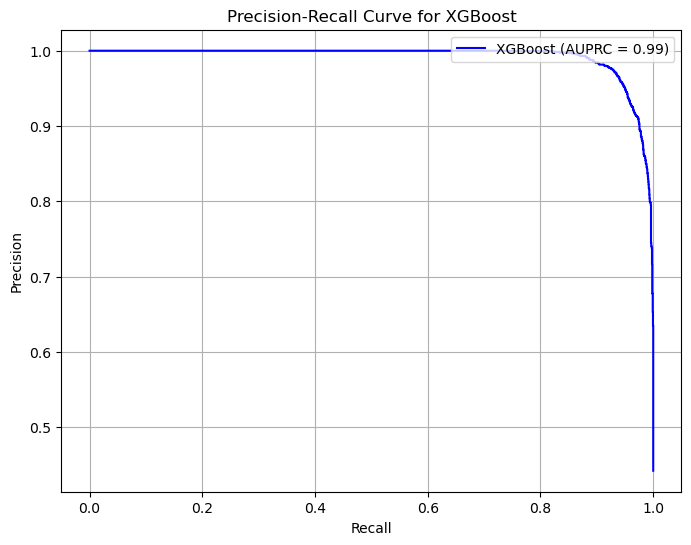

In [26]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Function to plot the Precision-Recall Curve
def plot_pr_curve(y_true, y_scores, model_name):
    precision, recall, _ = precision_recall_curve(y_true, y_scores)
    avg_precision = average_precision_score(y_true, y_scores)
    
    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, label=f'{model_name} (AUPRC = {avg_precision:.2f})', color='b')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve for {model_name}')
    plt.legend(loc="upper right")
    plt.grid(True)
    plt.show()

# Assuming 'random_search' holds the best estimator for each model
for model_name, model in models.items():
    print(f"Plotting AUPRC for {model_name}")
    
    best_estimator = random_search.best_estimator_
    
    # Get the predicted probabilities for the positive class
    y_scores = best_estimator.predict_proba(X_test)[:, 1]
    
    # Plot Precision-Recall Curve
    plot_pr_curve(y_test, y_scores, model_name)


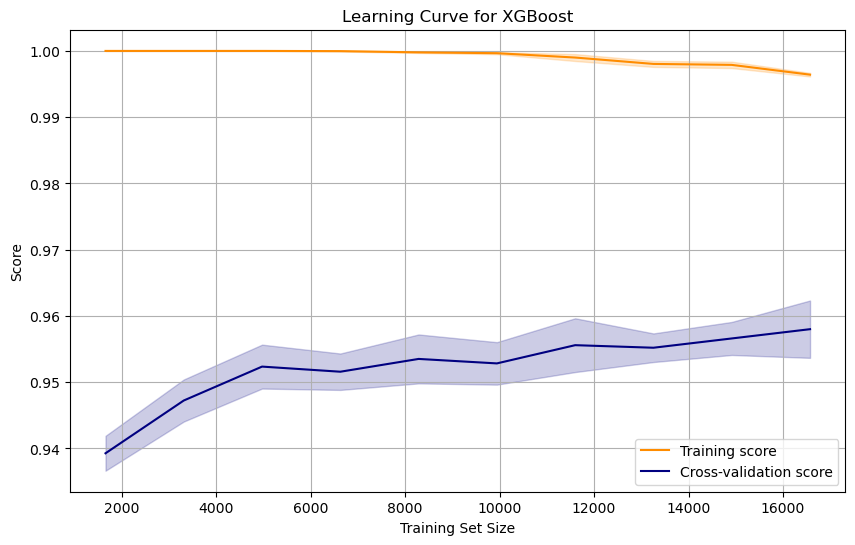

In [29]:
from sklearn.model_selection import learning_curve
xgb_model = xgb.XGBClassifier(eval_metric='mlogloss', random_state=42)

# Function to plot learning curve
def plot_learning_curve(estimator, X, y, title="Learning Curve for XGBoost", cv=5, scoring='accuracy'):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, scoring=scoring, n_jobs=-1, 
        train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
    )

    # Calculate the mean and standard deviation for both train and test scores
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    # Plot learning curve
    plt.figure(figsize=(10, 6))
    plt.title(title)
    plt.plot(train_sizes, train_scores_mean, label="Training score", color="darkorange")
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, color="darkorange", alpha=0.2)
    plt.plot(train_sizes, test_scores_mean, label="Cross-validation score", color="navy")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, color="navy", alpha=0.2)
    plt.xlabel("Training Set Size")
    plt.ylabel("Score")
    plt.legend(loc="best")
    plt.grid()
    plt.show()

# Plot the learning curve
plot_learning_curve(xgb_model, X_train, y_train, title="Learning Curve for XGBoost")

## Conclusion 
- XGBoost seems to be the better model based on the small performance edge in terms of accuracy and the fact that it has fewer n_estimators (100 vs. 200 for Gradient Boosting), which may lead to faster predictions. The subsample and colsample_bytree parameters suggest the model is using a more conservative approach in terms of data sampling, which might be helping in reducing overfitting.
- Gradient Boosting is still a very solid model and provides similar results with slight differences in the precision/recall balance for Class 1(Satisfied).

## **Feature Importance:** Analyzing feature importance can provide insights into the key drivers of predictions and help identify potential areas for improvement.

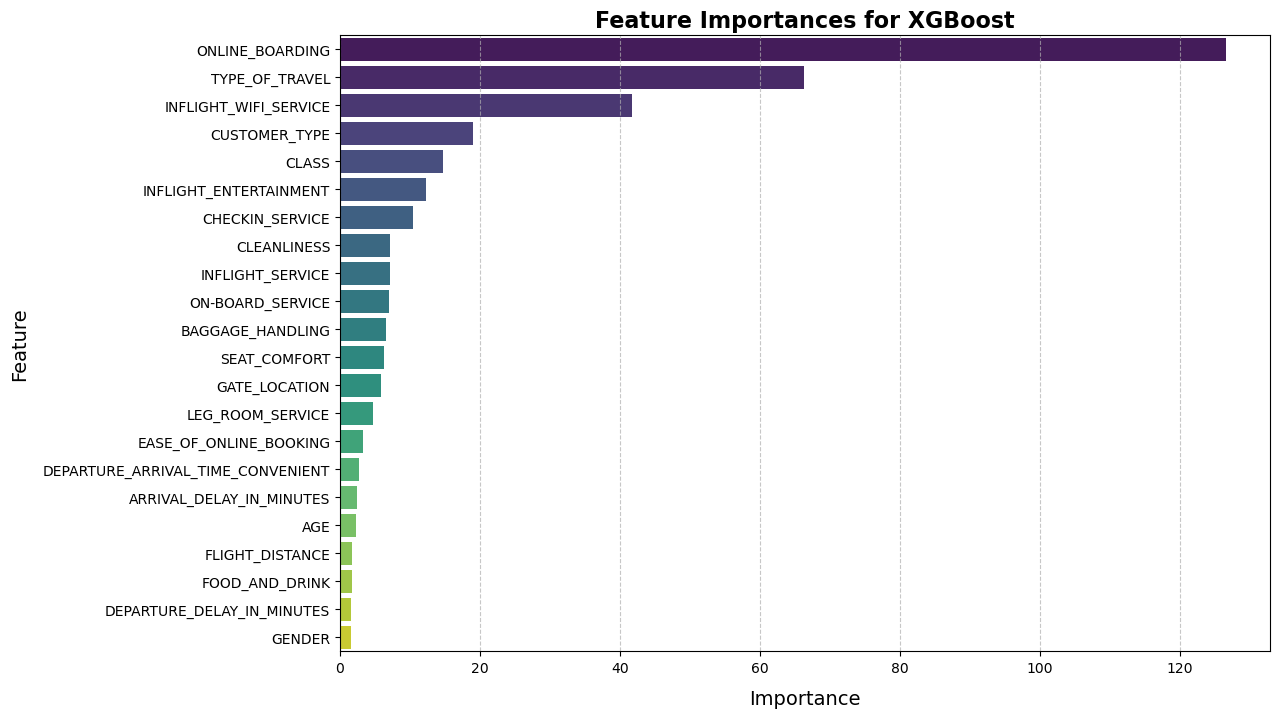

In [35]:
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Train the XGBoost model
xgb_model = xgb.XGBClassifier(eval_metric='mlogloss', random_state=42)
xgb_model.fit(X_train, y_train)

# Extract feature importances and create a DataFrame
feature_importances = xgb_model.get_booster().get_score(importance_type='gain')
feature_importance_df = pd.DataFrame(
    list(feature_importances.items()), columns=['Feature', 'Importance']
).sort_values(by='Importance', ascending=False)

# Plot feature importances using Seaborn for all features
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.xlabel('Importance', fontsize=14, labelpad=10)
plt.ylabel('Feature', fontsize=14, labelpad=10)
plt.title('Feature Importances for XGBoost', fontsize=16, weight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()


## Conclusion

**Model Performance:**

Based on the provided precision-recall curves, AUPRC scores, and learning curve, both XGBoost and Gradient Boosting demonstrate exceptional performance. The AUPRC values for both models are very close to 1, indicating high accuracy in classifying instances, particularly in the positive class (Satisfied).

**Model Comparison:**

* **XGBoost:**
    - Slightly higher AUPRC score, suggesting a potential edge in overall performance.
    - Fewer `n_estimators` (100 vs. 200 for Gradient Boosting), potentially leading to faster predictions.
    - Conservative approach with `subsample` and `colsample_bytree` parameters, potentially mitigating overfitting.
    - The learning curve shows a slight gap between the training and cross-validation scores, indicating some overfitting, but it's not significant.

* **Gradient Boosting:**
    - Strong performance comparable to XGBoost.
    - More `n_estimators`, potentially leading to higher accuracy but potentially slower predictions.

**Further Analysis:**

- **Error Analysis:** Examining misclassified instances can help identify patterns and areas where the models might be struggling.
- **Model Ensembling:** Combining the predictions of multiple models can often improve overall performance. Techniques like bagging and boosting can be explored.

